<a href="https://colab.research.google.com/github/Asuskf/from-nlp-to-agents/blob/tokens/tokens/GenAI_Unit_Economics_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT-5.6-Luna: Economic Viability & ROI Analysis of an LLM Application (corrected version)
**Model (hypothetical):** `gpt-5.6-luna`

**Context Window:** 1,050,000 tokens | **Max Output:** 128,000 tokens

**Pricing:** $1.00 / 1M input tokens | $6.00 / 1M output tokens

This notebook models the economic feasibility of an LLM application, based purely on token consumption. It includes:
1. **Microeconomics**: token-level cost per API call with Prompt Caching.
2. **Consumption patterns**: 🆕 **User ↔ Agent (conversational)** vs **A2A (Agent-to-Agent pipeline)** — with a comparative example.
3. **Cost structure**: Fixed (infrastructure) vs Variable (tokens).
4. **Financial metrics**: Break-Even Point (BEP) and ROI.
5. **Macroeconomics**: compute cost decay over time.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '${:,.4f}'.format

## 1. Microeconomics: token-level unit costs

Cost of a single API call, with prompt caching. The static prefix (typically the system prompt) can be cached; in OpenAI, cached input tokens cost **50%** of the standard input price and require a minimum prefix of ~1,024 tokens:

$$
\text{Cost}_{\text{query}} = (T_{in\_uncached} \times C_{in}) + (T_{in\_cached} \times C_{in} \times 0.5) + (T_{out} \times C_{out})
$$


In [9]:
class LunaEconomics:
    def __init__(self,
                 cost_per_1m_in: float = 1.00,
                 cost_per_1m_out: float = 6.00,
                 cache_discount: float = 0.50):
        """Prices are per 1,000,000 tokens."""
        self.cost_per_token_in = cost_per_1m_in / 1_000_000
        self.cost_per_token_out = cost_per_1m_out / 1_000_000
        self.cost_per_token_cached = self.cost_per_token_in * (1 - cache_discount)

    def query_cost(self,
                   cacheable_tokens: int,
                   uncached_input_tokens: int,
                   output_tokens: int,
                   cache_hit_rate: float = 0.80) -> float:
        """
        Cost of ONE API call.
        - cacheable_tokens: static prefix (e.g. the system prompt)
        - uncached_input_tokens: input that changes on every call (user message,
          conversation history, outputs from other agents)
        - cache_hit_rate: expected fraction of calls where the prefix hits the cache
        """
        cached = cacheable_tokens * cache_hit_rate
        uncached = cacheable_tokens * (1 - cache_hit_rate) + uncached_input_tokens
        in_cost = uncached * self.cost_per_token_in + cached * self.cost_per_token_cached
        out_cost = output_tokens * self.cost_per_token_out
        return in_cost + out_cost

luna = LunaEconomics()

# Quick example: 2,000-token system prompt, 300 user tokens, 500 output tokens
example_cost = luna.query_cost(cacheable_tokens=2000, uncached_input_tokens=300, output_tokens=500)
print(f"Cost of a single API call: ${example_cost:.5f}")

Cost of a single API call: $0.00450


## 2. 🆕 Two consumption patterns: User ↔ Agent vs A2A (Agent-to-Agent)

This is the key distinction the previous version confused. A process that **converses with the customer** is not the same as a pipeline where **the input is generated by agents** all the way to the output.

### 2a. User ↔ Agent (conversational)
```
Customer ──message──▶ [Agent] ──reply──▶ Customer ──message──▶ [Agent] ──▶ ...
```
- **Who generates the input:** the human. Each turn is 1 API call.
- **Cost driver:** the **history grows** on every turn (previous messages are re-sent as input tokens). Turn 8 is far more expensive than turn 1.
- **Pace:** limited by human speed (~turns per session, sessions per month).
- **Cache:** the system prompt is the stable prefix → high hit rate.

**Example:** a support chatbot. The customer writes *"my order didn't arrive"*, the agent replies, the customer follows up… 8 turns. Only the visible conversation consumes tokens.

### 2b. A2A — Agent-to-Agent (pipeline)
```
Input ──▶ [Planner] ──plan──▶ [Researcher] ──findings──▶ [Writer] ──draft──▶ [Reviewer] ──▶ Output
```
- **Who generates the input:** each agent consumes the **previous agent's output** as part of its input. The human only sees the final result (or not even that: the pipeline can be triggered by a cron job or a webhook).
- **Cost driver:** **token multiplication** — every intermediate output token is paid for twice or more: first as *output* of agent N, then as *input* of agent N+1 (and sometimes N+2, N+3...).
- **Pace:** no human slows it down → volume scales with automation, not with user patience.
- **Cache:** each agent has its own cacheable system prompt, but the intermediate content changes on every task → a smaller cacheable share.

**Example:** *"generate a market report"* → a Planner decomposes the task, a Researcher gathers and synthesizes, a Writer drafts, and a Reviewer corrects. A single customer "request" triggers **4 chained API calls** and thousands of tokens.

| | User ↔ Agent | A2A (pipeline) |
|---|---|---|
| Input origin | Human, turn by turn | Previous agent's output |
| API calls per interaction | 1 per turn | N agents per task (or more, with loops) |
| Token growth | Accumulated history | Intermediate outputs re-consumed |
| Volume limit | Human pace | Only budget / rate limits |
| Typical cost per interaction | Low-medium | High (token multiplication) |
| Accounting classification | **Variable** per user | **Variable** per task (⚠️ not fixed) |


In [10]:
# ---------- 2a. Cost of one conversational SESSION (User <-> Agent) ----------

def conversational_session_cost(model: LunaEconomics,
                                system_tokens: int = 2000,
                                user_msg_tokens: int = 300,
                                assistant_msg_tokens: int = 500,
                                turns: int = 8,
                                cache_hit_rate: float = 0.80) -> pd.DataFrame:
    """
    Models a multi-turn conversation.
    KEY FIX: at turn t, the input includes the ENTIRE previous history
    (t-1 user/assistant pairs), not just the new message.
    """
    rows = []
    for t in range(1, turns + 1):
        history_tokens = (t - 1) * (user_msg_tokens + assistant_msg_tokens)
        uncached_in = user_msg_tokens + history_tokens
        cost = model.query_cost(system_tokens, uncached_in, assistant_msg_tokens, cache_hit_rate)
        rows.append({'Turn': t, 'Variable_Input_Tokens': uncached_in, 'Turn_Cost': cost})
    df = pd.DataFrame(rows)
    df['Cumulative_Cost'] = df['Turn_Cost'].cumsum()
    return df

df_chat = conversational_session_cost(luna)
session_cost = df_chat['Turn_Cost'].sum()
display(df_chat)
print(f"Total session cost (8 turns): ${session_cost:.4f}")
print(f"Turn 8 costs {df_chat['Turn_Cost'].iloc[-1] / df_chat['Turn_Cost'].iloc[0]:.1f}x turn 1 (due to history growth)")

,Turn,Variable_Input_Tokens,Turn_Cost,Cumulative_Cost
0,1,300,$0.00,$0.00
1,2,1100,$0.01,$0.01
2,3,1900,$0.01,$0.02
3,4,2700,$0.01,$0.02
4,5,3500,$0.01,$0.03
5,6,4300,$0.01,$0.04
6,7,5100,$0.01,$0.05
7,8,5900,$0.01,$0.06


Total session cost (8 turns): $0.0584
Turn 8 costs 2.2x turn 1 (due to history growth)


In [11]:
# ---------- 2b. Cost of one A2A TASK (agent pipeline) ----------

def a2a_task_cost(model: LunaEconomics,
                  pipeline: list,
                  cache_hit_rate: float = 0.60) -> pd.DataFrame:
    """
    Pipeline: list of agents. Each agent's output is added to the
    next agent's input (token multiplication).
    Each dict: {'agent', 'system_tokens', 'extra_input_tokens', 'output_tokens'}
    - extra_input_tokens: step-specific input tokens (e.g. the original task,
      or any additional text this step receives)
    """
    rows = []
    carried_tokens = 0  # tokens produced by previous agents that this step consumes
    for step in pipeline:
        uncached_in = step['extra_input_tokens'] + carried_tokens
        cost = model.query_cost(step['system_tokens'], uncached_in,
                                step['output_tokens'], cache_hit_rate)
        rows.append({
            'Agent': step['agent'],
            'Input_Inherited_From_Previous_Agents': carried_tokens,
            'Own_Input': step['extra_input_tokens'],
            'Output': step['output_tokens'],
            'Step_Cost': cost
        })
        # This agent's output becomes input for the next one
        carried_tokens += step['output_tokens']
    df = pd.DataFrame(rows)
    df['Cumulative_Cost'] = df['Step_Cost'].cumsum()
    return df

# Task: "Generate a market report" -> 4 chained agents
report_pipeline = [
    {'agent': '1. Planner',    'system_tokens': 1500, 'extra_input_tokens': 200,  'output_tokens': 400},
    {'agent': '2. Researcher', 'system_tokens': 1500, 'extra_input_tokens': 3000, 'output_tokens': 1500},
    {'agent': '3. Writer',     'system_tokens': 1500, 'extra_input_tokens': 0,    'output_tokens': 2500},
    {'agent': '4. Reviewer',   'system_tokens': 1000, 'extra_input_tokens': 0,    'output_tokens': 600},
]

df_a2a = a2a_task_cost(luna, report_pipeline)
task_cost = df_a2a['Step_Cost'].sum()
display(df_a2a)
print(f"Total cost of ONE A2A task (4 agents): ${task_cost:.4f}")

,Agent,Input_Inherited_From_Previous_Agents,Own_Input,Output,Step_Cost,Cumulative_Cost
0,1. Planner,0,200,400,$0.00,$0.00
1,2. Researcher,400,3000,1500,$0.01,$0.02
2,3. Writer,1900,0,2500,$0.02,$0.04
3,4. Reviewer,4400,0,600,$0.01,$0.04


Total cost of ONE A2A task (4 agents): $0.0437


  Chat - average cost per turn (1 request):      $0.0073
  A2A  - cost per task (1 request, 4 API calls): $0.0437
  -> One A2A request costs 6.0x one chat request
  (Full chat session, 8 turns: $0.0584)


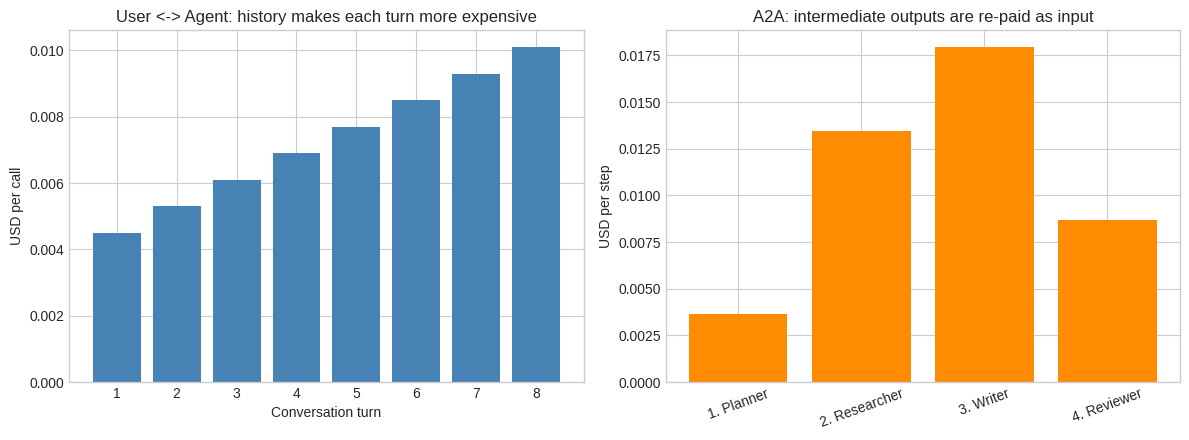

In [12]:
# ---------- Direct comparison (per USER REQUEST) ----------
# Fair unit of comparison: 1 user request.
# - Chat: 1 request = 1 turn (1 API call)
# - A2A:  1 request = 1 full task (N chained API calls)
avg_turn_cost = session_cost / len(df_chat)
ratio = task_cost / avg_turn_cost

print("=" * 66)
print(f"  Chat - average cost per turn (1 request):      ${avg_turn_cost:.4f}")
print(f"  A2A  - cost per task (1 request, 4 API calls): ${task_cost:.4f}")
print(f"  -> One A2A request costs {ratio:.1f}x one chat request")
print(f"  (Full chat session, 8 turns: ${session_cost:.4f})")
print("=" * 66)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(df_chat['Turn'].astype(str), df_chat['Turn_Cost'], color='steelblue')
axes[0].set_title('User <-> Agent: history makes each turn more expensive')
axes[0].set_xlabel('Conversation turn')
axes[0].set_ylabel('USD per call')

axes[1].bar(df_a2a['Agent'], df_a2a['Step_Cost'], color='darkorange')
axes[1].set_title('A2A: intermediate outputs are re-paid as input')
axes[1].set_ylabel('USD per step')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Reading the result:** in chat, cost grows because the history is re-sent; in A2A, it grows because every intermediate output becomes the next agent's input. When budgeting, the variable cost per user must therefore be computed from the **real mix**: how many chat sessions and how many A2A tasks a user triggers per month.


In [13]:
# ---------- Monthly variable cost per user (mix of both patterns) ----------

def monthly_variable_cost_per_user(chat_sessions_per_month: int,
                                   a2a_tasks_per_month: int,
                                   session_cost: float,
                                   task_cost: float) -> float:
    return chat_sessions_per_month * session_cost + a2a_tasks_per_month * task_cost

# Typical user: 12 chat sessions + 6 A2A tasks per month
monthly_cost_per_user = monthly_variable_cost_per_user(
    chat_sessions_per_month=12,
    a2a_tasks_per_month=6,
    session_cost=session_cost,
    task_cost=task_cost
)
print(f"Monthly variable cost per user: ${monthly_cost_per_user:.4f}")

Monthly variable cost per user: $0.9633


## 3. Cost structure: Fixed (infrastructure) vs Variable (tokens) and ROI

**Conceptual fix:** what is fixed is the **infrastructure** (hosting, API gateway, orchestration). A2A consumption is **not** fixed: it is variable and already included in `monthly_cost_per_user`.

$$
\text{BEP (users)} = \frac{\text{Fixed Costs}}{\text{Revenue per user} - \text{Variable cost per user}}
$$


In [14]:
class FinancialProjections:
    def __init__(self, fixed_monthly_cost: float, customer_revenue_monthly: float):
        self.fixed_monthly_cost = fixed_monthly_cost
        self.customer_revenue_monthly = customer_revenue_monthly

    def break_even_point(self, variable_cost_per_user: float) -> float:
        margin = self.customer_revenue_monthly - variable_cost_per_user
        if margin <= 0:
            raise ValueError("Not viable: variable cost per user exceeds revenue per user.")
        return self.fixed_monthly_cost / margin

    def quarterly_roi_projection(self,
                                 variable_cost_per_user: float,
                                 initial_investment: float,
                                 user_growth_trajectory: list) -> pd.DataFrame:
        n_quarters = len(user_growth_trajectory)
        fixed_q = self.fixed_monthly_cost * 3
        revenue_q = self.customer_revenue_monthly * 3
        variable_q = variable_cost_per_user * 3
        df = pd.DataFrame({
            'Quarter': [f"Q{i+1}" for i in range(n_quarters)],
            'Avg_Active_Users': user_growth_trajectory,
            'Revenue': [u * revenue_q for u in user_growth_trajectory],
            'Fixed_Infra_Costs': [fixed_q] * n_quarters,   # FIXED: was misnamed "Fixed_A2A_Costs"
            'Variable_LLM_Costs': [u * variable_q for u in user_growth_trajectory],
        })
        df['Total_Costs'] = df['Fixed_Infra_Costs'] + df['Variable_LLM_Costs']
        df['Net_Income'] = df['Revenue'] - df['Total_Costs']
        df['Cumulative_Net_Income'] = df['Net_Income'].cumsum()
        df['Cumulative_ROI_%'] = df['Cumulative_Net_Income'] / initial_investment * 100
        return df

# $3,500/month of infrastructure, charging $15.00/month per user
finances = FinancialProjections(fixed_monthly_cost=3500, customer_revenue_monthly=15.00)

bep_users = finances.break_even_point(monthly_cost_per_user)
print(f"Break-even point: {int(np.ceil(bep_users))} active users")

user_projection = [300, 800, 1500, 3000, 5000, 8000]
df_projections = finances.quarterly_roi_projection(
    variable_cost_per_user=monthly_cost_per_user,
    initial_investment=40000,
    user_growth_trajectory=user_projection
)
pd.options.display.float_format = '${:,.2f}'.format
display(df_projections)

Break-even point: 250 active users


,Quarter,Avg_Active_Users,Revenue,Fixed_Infra_Costs,Variable_LLM_Costs,Total_Costs,Net_Income,Cumulative_Net_Income,Cumulative_ROI_%
0,Q1,300,"$13,500.00",10500,$866.97,"$11,366.97","$2,133.03","$2,133.03",$5.33
1,Q2,800,"$36,000.00",10500,"$2,311.92","$12,811.92","$23,188.08","$25,321.11",$63.30
2,Q3,1500,"$67,500.00",10500,"$4,334.85","$14,834.85","$52,665.15","$77,986.26",$194.97
3,Q4,3000,"$135,000.00",10500,"$8,669.70","$19,169.70","$115,830.30","$193,816.56",$484.54
4,Q5,5000,"$225,000.00",10500,"$14,449.50","$24,949.50","$200,050.50","$393,867.06",$984.67
5,Q6,8000,"$360,000.00",10500,"$23,119.20","$33,619.20","$326,380.80","$720,247.86","$1,800.62"


## 4. Macroeconomics: API cost decay and scale

Historically, the price per token drops over time (better hardware, better inference algorithms). This is modeled with a compounded **quarterly decay rate** applied to the variable cost.


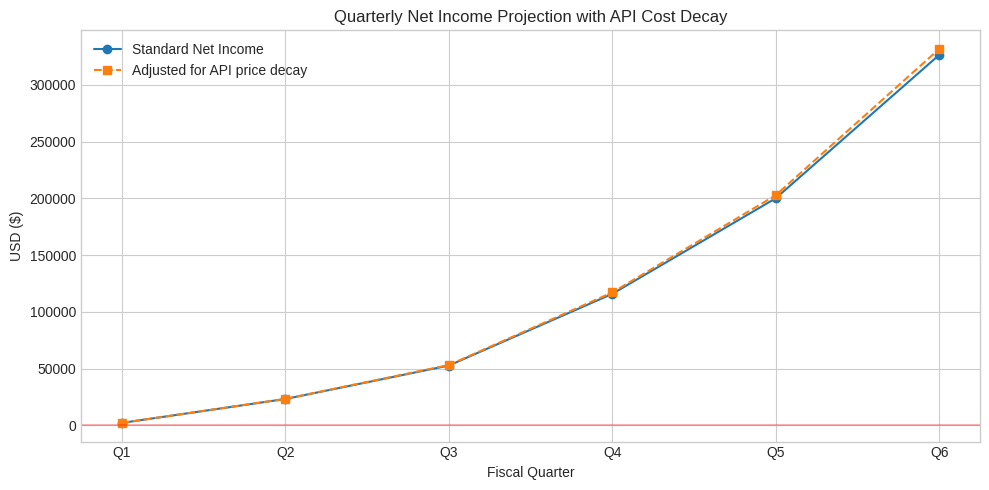

In [15]:
def macro_simulation(df: pd.DataFrame, api_cost_decay_rate: float = 0.05) -> pd.DataFrame:
    """api_cost_decay_rate: expected % reduction in API cost per quarter."""
    df_macro = df.copy()
    decay = [(1 - api_cost_decay_rate) ** i for i in range(len(df_macro))]
    df_macro['Macro_LLM_Costs'] = df_macro['Variable_LLM_Costs'] * decay
    df_macro['Macro_Net_Income'] = df_macro['Revenue'] - (df_macro['Fixed_Infra_Costs'] + df_macro['Macro_LLM_Costs'])
    return df_macro

df_macro = macro_simulation(df_projections, api_cost_decay_rate=0.05)

plt.figure(figsize=(10, 5))
plt.plot(df_macro['Quarter'], df_macro['Net_Income'], label='Standard Net Income', marker='o')
plt.plot(df_macro['Quarter'], df_macro['Macro_Net_Income'], label='Adjusted for API price decay', marker='s', linestyle='--')
plt.title('Quarterly Net Income Projection with API Cost Decay')
plt.xlabel('Fiscal Quarter')
plt.ylabel('USD ($)')
plt.axhline(0, color='red', linestyle='-', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Advanced break-even analysis: Volume, Price, and Target Costing

**1. Required volume:**
$$\text{Volume} = \frac{\text{Fixed Costs}}{\text{Price} - \text{Variable Cost}}$$

**2. Minimum viable price:**
$$\text{Price} = \frac{\text{Fixed Costs}}{\text{Target Users}} + \text{Variable Cost}$$

**3. Maximum allowable variable cost (target costing):**
$$\text{Max Cost} = \text{Price} - \frac{\text{Fixed Costs}}{\text{Target Users}}$$


Computed variable cost per user: $0.96/month

1. Volume needed: 250 users to break even at $15/month.
2. Minimum price: $18.46/month to break even with 200 users.
3. Max allowable LLM cost: $3.00/user at $10/month with 500 users.


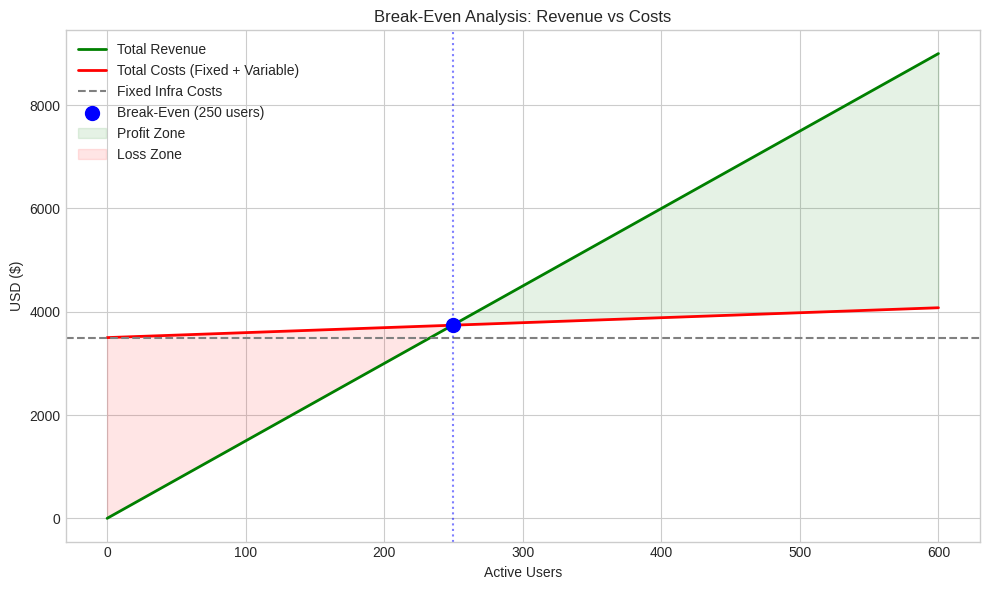

In [16]:
class AdvancedBreakEven:
    def __init__(self, fixed_monthly_cost: float):
        self.fixed_monthly_cost = fixed_monthly_cost

    def required_volume(self, price_per_user: float, variable_cost_per_user: float) -> float:
        margin = price_per_user - variable_cost_per_user
        if margin <= 0:
            return float('inf')
        return self.fixed_monthly_cost / margin

    def required_price(self, target_users: int, variable_cost_per_user: float) -> float:
        return self.fixed_monthly_cost / target_users + variable_cost_per_user

    def target_variable_cost(self, price_per_user: float, target_users: int) -> float:
        return price_per_user - self.fixed_monthly_cost / target_users

    def plot_break_even_chart(self, price_per_user: float, variable_cost_per_user: float, max_users: int):
        users = np.linspace(0, max_users, 100)
        revenue = users * price_per_user
        total_costs = self.fixed_monthly_cost + users * variable_cost_per_user
        bep = self.required_volume(price_per_user, variable_cost_per_user)

        plt.figure(figsize=(10, 6))
        plt.plot(users, revenue, label='Total Revenue', color='green', linewidth=2)
        plt.plot(users, total_costs, label='Total Costs (Fixed + Variable)', color='red', linewidth=2)
        plt.axhline(self.fixed_monthly_cost, color='gray', linestyle='--', label='Fixed Infra Costs')
        if bep <= max_users:
            plt.scatter(bep, bep * price_per_user, color='blue', s=100, zorder=5,
                        label=f'Break-Even ({int(np.ceil(bep))} users)')
            plt.axvline(bep, color='blue', linestyle=':', alpha=0.5)
        plt.fill_between(users, revenue, total_costs, where=(revenue > total_costs),
                         interpolate=True, color='green', alpha=0.1, label='Profit Zone')
        plt.fill_between(users, revenue, total_costs, where=(revenue <= total_costs),
                         interpolate=True, color='red', alpha=0.1, label='Loss Zone')
        plt.title('Break-Even Analysis: Revenue vs Costs')
        plt.xlabel('Active Users')
        plt.ylabel('USD ($)')
        plt.legend()
        plt.tight_layout()
        plt.show()

be_analysis = AdvancedBreakEven(fixed_monthly_cost=3500)

# FIXED: uses the computed variable (monthly_cost_per_user), not a hardcoded $2.50
print(f"Computed variable cost per user: ${monthly_cost_per_user:.2f}/month\n")

bep_volume = be_analysis.required_volume(price_per_user=15.00, variable_cost_per_user=monthly_cost_per_user)
print(f"1. Volume needed: {int(np.ceil(bep_volume))} users to break even at $15/month.")

min_price = be_analysis.required_price(target_users=200, variable_cost_per_user=monthly_cost_per_user)
print(f"2. Minimum price: ${min_price:.2f}/month to break even with 200 users.")

max_llm_cost = be_analysis.target_variable_cost(price_per_user=10.00, target_users=500)
print(f"3. Max allowable LLM cost: ${max_llm_cost:.2f}/user at $10/month with 500 users.")

be_analysis.plot_break_even_chart(price_per_user=15.00, variable_cost_per_user=monthly_cost_per_user, max_users=600)

## 6. 🆕 Break-even split by consumption pattern: Users vs Agent (A2A) input/output

A single blended break-even hides which side of the business is (or isn't) viable. Here we split it into two independent product lines, each with its own revenue model and its own variable token cost:

**Line A — Conversational users (User ↔ Agent):** subscription revenue per user/month vs the monthly chat token cost per user.

$$
\text{BEP}_{\text{users}} = \frac{\text{Fixed Costs}_{\text{chat}}}{\text{Subscription} - \text{Chat token cost per user/month}}
$$

**Line B — A2A tasks (Agent → Agent):** usage-based revenue per task vs the token cost per task, where the cost decomposes into **agent input tokens** (inherited outputs + own input + system prompts) and **agent output tokens**:

$$
\text{BEP}_{\text{tasks}} = \frac{\text{Fixed Costs}_{\text{A2A}}}{\text{Price per task} - (\text{Cost}_{\text{agent input}} + \text{Cost}_{\text{agent output}})}
$$

Fixed infrastructure costs are allocated between the two lines with a parameter (`fixed_alloc_chat`), so each line must cover its own share.


In [17]:
# ---------- Input vs Output token cost decomposition ----------

def query_cost_breakdown(model: LunaEconomics,
                         cacheable_tokens: int,
                         uncached_input_tokens: int,
                         output_tokens: int,
                         cache_hit_rate: float) -> dict:
    """Splits the cost of one API call into input-token cost and output-token cost."""
    cached = cacheable_tokens * cache_hit_rate
    uncached = cacheable_tokens * (1 - cache_hit_rate) + uncached_input_tokens
    input_cost = uncached * model.cost_per_token_in + cached * model.cost_per_token_cached
    output_cost = output_tokens * model.cost_per_token_out
    return {'input_cost': input_cost, 'output_cost': output_cost}

# --- Chat session: input vs output split (same parameters as Section 2a) ---
chat_in, chat_out = 0.0, 0.0
for t in range(1, 9):
    history = (t - 1) * (300 + 500)
    b = query_cost_breakdown(luna, cacheable_tokens=2000,
                             uncached_input_tokens=300 + history,
                             output_tokens=500, cache_hit_rate=0.80)
    chat_in += b['input_cost']
    chat_out += b['output_cost']

# --- A2A task: input vs output split (same pipeline as Section 2b) ---
a2a_in, a2a_out = 0.0, 0.0
carried = 0
for step in report_pipeline:
    b = query_cost_breakdown(luna, cacheable_tokens=step['system_tokens'],
                             uncached_input_tokens=step['extra_input_tokens'] + carried,
                             output_tokens=step['output_tokens'], cache_hit_rate=0.60)
    a2a_in += b['input_cost']
    a2a_out += b['output_cost']
    carried += step['output_tokens']

df_split = pd.DataFrame({
    'Pattern': ['Chat session (8 turns)', 'A2A task (4 agents)'],
    'Input_Token_Cost': [chat_in, a2a_in],
    'Output_Token_Cost': [chat_out, a2a_out],
})
df_split['Total'] = df_split['Input_Token_Cost'] + df_split['Output_Token_Cost']
df_split['Input_%'] = df_split['Input_Token_Cost'] / df_split['Total'] * 100
df_split['Output_%'] = df_split['Output_Token_Cost'] / df_split['Total'] * 100
pd.options.display.float_format = '${:,.4f}'.format
display(df_split)
print(f"Chat: input tokens are {df_split['Input_%'][0]:.0f}% of the cost - driven by the re-sent conversation history.")
print(f"A2A:  output tokens are {df_split['Output_%'][1]:.0f}% of the cost - agents generate long intermediate outputs,")
print(f"      and each one is then re-paid as INPUT by every downstream agent (${a2a_in:.4f} of input cost per task).")

,Pattern,Input_Token_Cost,Output_Token_Cost,Total,Input_%,Output_%
0,Chat session (8 turns),$0.0344,$0.0240,$0.0584,$58.9041,$41.0959
1,A2A task (4 agents),$0.0137,$0.0300,$0.0437,$31.4286,$68.5714


Chat: input tokens are 59% of the cost - driven by the re-sent conversation history.
A2A:  output tokens are 69% of the cost - agents generate long intermediate outputs,
      and each one is then re-paid as INPUT by every downstream agent ($0.0137 of input cost per task).


  Fixed cost allocation: $1,750/mo to chat | $1,750/mo to A2A
----------------------------------------------------------------------
  Line A - USERS:     chat cost $0.70/user/mo vs $15.00 subscription
                      -> BEP = 123 active users
  Line B - A2A TASKS: cost $0.0437/task (input $0.0137 + output $0.0300) vs $0.25/task
                      -> BEP = 8,485 tasks/month


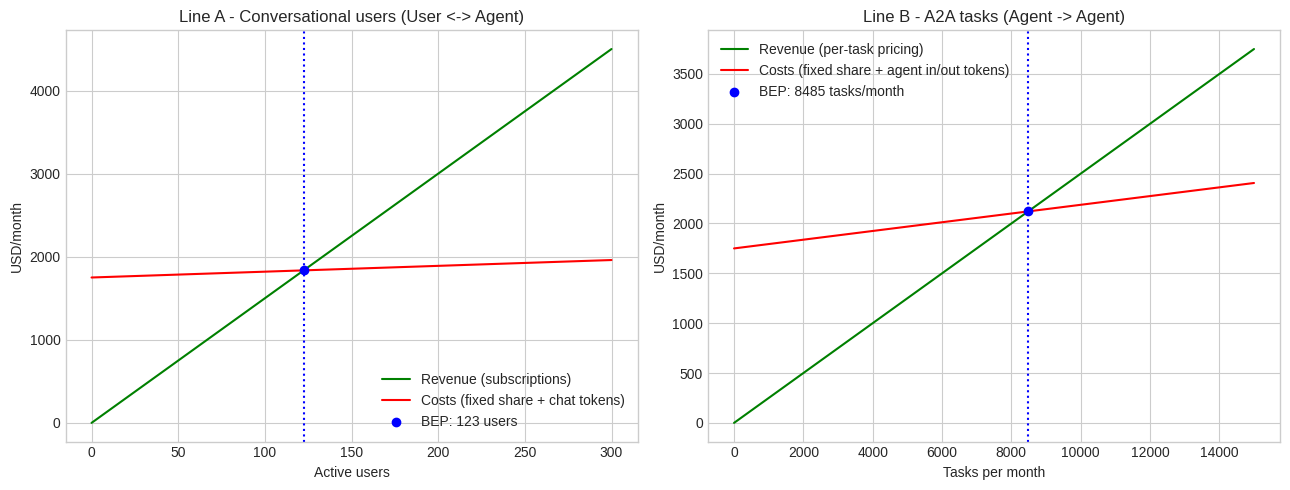

In [18]:
# ---------- Segmented break-even: Users (chat) vs A2A tasks ----------

class SegmentedBreakEven:
    def __init__(self, fixed_monthly_cost: float, fixed_alloc_chat: float = 0.5):
        """
        fixed_alloc_chat: fraction of fixed infrastructure costs allocated to the
        conversational line; the remainder goes to the A2A line.
        """
        self.fixed_chat = fixed_monthly_cost * fixed_alloc_chat
        self.fixed_a2a = fixed_monthly_cost * (1 - fixed_alloc_chat)

    def bep_users(self, subscription_price: float, chat_cost_per_user_month: float) -> float:
        """Break-even in USERS for the conversational line."""
        margin = subscription_price - chat_cost_per_user_month
        if margin <= 0:
            return float('inf')
        return self.fixed_chat / margin

    def bep_a2a_tasks(self, price_per_task: float, cost_per_task: float) -> float:
        """Break-even in TASKS/month for the A2A line (agent input + output tokens)."""
        margin = price_per_task - cost_per_task
        if margin <= 0:
            return float('inf')
        return self.fixed_a2a / margin

    def plot(self, subscription_price, chat_cost_per_user_month, max_users,
             price_per_task, cost_per_task, max_tasks):
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # --- Line A: conversational users ---
        users = np.linspace(0, max_users, 100)
        rev_u = users * subscription_price
        cost_u = self.fixed_chat + users * chat_cost_per_user_month
        bep_u = self.bep_users(subscription_price, chat_cost_per_user_month)
        axes[0].plot(users, rev_u, color='green', label='Revenue (subscriptions)')
        axes[0].plot(users, cost_u, color='red', label='Costs (fixed share + chat tokens)')
        if bep_u <= max_users:
            axes[0].axvline(bep_u, color='blue', linestyle=':')
            axes[0].scatter(bep_u, bep_u * subscription_price, color='blue', zorder=5,
                            label=f'BEP: {int(np.ceil(bep_u))} users')
        axes[0].set_title('Line A - Conversational users (User <-> Agent)')
        axes[0].set_xlabel('Active users')
        axes[0].set_ylabel('USD/month')
        axes[0].legend()

        # --- Line B: A2A tasks ---
        tasks = np.linspace(0, max_tasks, 100)
        rev_t = tasks * price_per_task
        cost_t = self.fixed_a2a + tasks * cost_per_task
        bep_t = self.bep_a2a_tasks(price_per_task, cost_per_task)
        axes[1].plot(tasks, rev_t, color='green', label='Revenue (per-task pricing)')
        axes[1].plot(tasks, cost_t, color='red', label='Costs (fixed share + agent in/out tokens)')
        if bep_t <= max_tasks:
            axes[1].axvline(bep_t, color='blue', linestyle=':')
            axes[1].scatter(bep_t, bep_t * price_per_task, color='blue', zorder=5,
                            label=f'BEP: {int(np.ceil(bep_t))} tasks/month')
        axes[1].set_title('Line B - A2A tasks (Agent -> Agent)')
        axes[1].set_xlabel('Tasks per month')
        axes[1].set_ylabel('USD/month')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

# --- Scenario ---
# Line A: subscription $15/month; chat cost per user = 12 sessions/month
chat_cost_per_user_month = 12 * session_cost

# Line B: usage-based pricing at $0.25 per A2A task; cost per task from Section 2b
price_per_task = 0.25

seg = SegmentedBreakEven(fixed_monthly_cost=3500, fixed_alloc_chat=0.5)

bep_u = seg.bep_users(subscription_price=15.00, chat_cost_per_user_month=chat_cost_per_user_month)
bep_t = seg.bep_a2a_tasks(price_per_task=price_per_task, cost_per_task=task_cost)

print("=" * 70)
print(f"  Fixed cost allocation: ${seg.fixed_chat:,.0f}/mo to chat | ${seg.fixed_a2a:,.0f}/mo to A2A")
print("-" * 70)
print(f"  Line A - USERS:     chat cost ${chat_cost_per_user_month:.2f}/user/mo vs $15.00 subscription")
print(f"                      -> BEP = {int(np.ceil(bep_u))} active users")
print(f"  Line B - A2A TASKS: cost ${task_cost:.4f}/task (input ${a2a_in:.4f} + output ${a2a_out:.4f}) vs ${price_per_task:.2f}/task")
print(f"                      -> BEP = {int(np.ceil(bep_t)):,} tasks/month")
print("=" * 70)

seg.plot(subscription_price=15.00, chat_cost_per_user_month=chat_cost_per_user_month, max_users=300,
         price_per_task=price_per_task, cost_per_task=task_cost, max_tasks=15000)